# Method comparison: Carleman+QSVT vs. Variational

Team: Andrei Poliakov, Kyro Jeremy Gibling, Nadav Carmel, Pak Tik, Sahil Ugale

Same problem instance (grid, dt, IC, physical parameter) for both PDEs, run through both
pathways, so accuracy and resource cost are directly comparable.

Two constraints shaped the setup: Burgers' main Carleman notebook uses Dirichlet BC while
everything else here is periodic, so `periodic_burgers.py` provides a periodic version just for
this comparison; and Pauli-LCU's cost is intractable above N~6, so it's reported separately at its
own N=5 rather than forced onto this notebook's N=8. Both methods are checked against the same
exact-ODE (RK45) reference, since Carleman uses implicit Euler and variational uses explicit Euler
internally.


In [1]:
import sys, os, importlib.util

sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../carleman_qsvt"))

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector

from discretization import periodic_D2, periodic_D3, construct_F2_periodic

# carleman_qsvt/burgers.py and variational/burgers.py share a module name; load the
# variational one explicitly to avoid the collision.
from burgers import compute_inverse_qsvt_angles, block_encode_matrix, next_power_of_two
from periodic_burgers import PeriodicBurgers_Carlemann
from kdv import KdV_Carlemann
import resource_estimation as res_est


def _load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod


_variational_dir = os.path.abspath("../variational")
sys.path.insert(0, _variational_dir)
pde_core = _load_module("pde_core", os.path.join(_variational_dir, "pde_core.py"))
_variational_burgers = _load_module("variational_burgers_impl", os.path.join(_variational_dir, "burgers.py"))

ansatz = pde_core.ansatz
get_state = pde_core.get_state
get_expval_ideal = pde_core.get_expval_ideal
num_ansatz_params = pde_core.num_ansatz_params
hadamard_test = pde_core.hadamard_test
nonlinear_overlap = pde_core.nonlinear_overlap
shift_power = pde_core.shift_power
variational_burgers_cost = _variational_burgers.burgers_cost

from kdv_general_n import kdv_cost_general

CLASSICAL_COLOR = "#52514e"
DENSE_COLOR = "#2a78d6"
VARIATIONAL_COLOR = "#eb6834"


## Parameters

N=8 for both PDEs. cos(4*pi*x) (the challenge's suggested KdV IC) has a zero discrete nonlinear
term at N=8 (same aliasing issue as at N=4), so cos(2*pi*x) is used instead.


In [2]:
N = 8
N_T = 2
n = 3  # qubits, N = 2**n

nu = 0.01
dt_burgers = 0.06
n_steps_burgers = 5
ic_burgers = "sin"

delta = 0.0533
dt_kdv = 0.005
n_steps_kdv = 4
ic_kdv = "cos2"

x = np.linspace(0, 1, N, endpoint=False)
dx = x[1] - x[0]
u0_burgers = np.sin(2 * np.pi * x)
u0_kdv = np.cos(2 * np.pi * x)

print(f"dx = {dx}")
print(f"Burgers: nu={nu}, dt={dt_burgers}, {n_steps_burgers} steps, u0=sin(2*pi*x)")
print(f"KdV:     delta={delta}, dt={dt_kdv}, {n_steps_kdv} steps, u0=cos(2*pi*x)")


dx = 0.125
Burgers: nu=0.01, dt=0.06, 5 steps, u0=sin(2*pi*x)
KdV:     delta=0.0533, dt=0.005, 4 steps, u0=cos(2*pi*x)


## Ground truth: exact nonlinear ODE (RK45)


In [3]:
def exact_ode_reference(u0, F1, F2, dt, n_steps):
    from scipy.integrate import solve_ivp

    def rhs(t, y):
        return F1 @ y + F2 @ np.kron(y, y)

    t_eval = np.linspace(0, n_steps * dt, n_steps + 1)
    sol = solve_ivp(rhs, (0, n_steps * dt), u0, t_eval=t_eval, method="RK45", rtol=1e-10, atol=1e-12)
    assert sol.success, sol.message
    return sol.y.T  # shape (n_steps+1, N)


F1_burgers = nu * periodic_D2(N, dx)
F2 = -1 / (2 * dx) * construct_F2_periodic(N)
F1_kdv = -delta * periodic_D3(N, dx)

exact_burgers = exact_ode_reference(u0_burgers, F1_burgers, F2, dt_burgers, n_steps_burgers)
exact_kdv = exact_ode_reference(u0_kdv, F1_kdv, F2, dt_kdv, n_steps_kdv)
print("exact reference computed for both PDEs")


exact reference computed for both PDEs


## Carleman + Dense-QSVT


In [4]:
kappa = 8
phi_qsvt, s = compute_inverse_qsvt_angles(kappa, tolerance=1e-5)
print(f"{len(phi_qsvt)} phase angles")

pb_carleman = PeriodicBurgers_Carlemann(N, N_T, n_steps_burgers * dt_burgers, nu, dt_burgers, ic=ic_burgers)
kdv_carleman = KdV_Carlemann(N, N_T, n_steps_kdv * dt_kdv, delta, dt_kdv, ic="cos2")

y_burgers_qsvt, rmse_burgers_qsvt, psucc_burgers_qsvt = pb_carleman.get_implicit_solver_qsvt(phi_qsvt, s, verbose=False)
y_kdv_qsvt, rmse_kdv_qsvt, psucc_kdv_qsvt = kdv_carleman.get_implicit_solver_qsvt(phi_qsvt, s, verbose=False)

print("Burgers Dense-QSVT RMSE vs. its own exact-ODE reference:", rmse_burgers_qsvt)
print("KdV     Dense-QSVT RMSE vs. its own exact-ODE reference:", rmse_kdv_qsvt)


b=280, j0=51
[PolyOneOverX] minimum [-10.69067105] is at [-0.06701114]: normalizing
[PolyOneOverX] bounding to 0.9


560 phase angles


Burgers Dense-QSVT RMSE vs. its own exact-ODE reference: [0.02294615 0.0761561  0.14130577 0.29864636 0.33429523]
KdV     Dense-QSVT RMSE vs. its own exact-ODE reference: [0.00223594 0.00447063 0.00677055 0.00919414]


## Variational


In [5]:
nparams = num_ansatz_params(n)


def fit_initial_state(u0, n_restarts=8):
    amp0 = np.linalg.norm(u0)
    u0n = u0 / amp0

    def loss(theta):
        v = np.real(Statevector(ansatz(n, theta)).data)
        return np.sum((v - u0n) ** 2)

    best = None
    for trial in range(n_restarts):
        theta0 = np.random.default_rng(trial).random(nparams) * 2 * np.pi
        res = sp.optimize.minimize(loss, theta0, method="BFGS")
        if best is None or res.fun < best.fun:
            best = res
    return np.concatenate(([amp0], best.x)), best.fun


def run_variational(u0, cost_fn, cost_args, n_steps, seed_base, n_restarts=6, maxiter=400):
    theta0, resid = fit_initial_state(u0)
    print(f"  encoding fit residual: {resid:.2e}")
    theta = theta0.copy()
    states = [get_state(n, theta)]
    for step in range(n_steps):
        def objective(theta_new):
            cost, _ = cost_fn(theta_new, theta, *cost_args, get_expval_ideal)
            return cost

        best_new = None
        for trial in range(n_restarts):
            guess = theta + np.random.default_rng(seed_base + 10 * step + trial).normal(scale=0.05, size=nparams + 1)
            res = sp.optimize.minimize(objective, guess, method="COBYLA", options={"maxiter": maxiter})
            if best_new is None or res.fun < best_new.fun:
                best_new = res
        theta = best_new.x
        states.append(get_state(n, theta))
        print(f"  step {step+1}/{n_steps}: cost={best_new.fun:.5f}")
    return np.array(states)


print("Burgers variational:")
y_burgers_var = run_variational(u0_burgers, variational_burgers_cost, (n, dt_burgers, dx, nu), n_steps_burgers, seed_base=2000)

print("KdV variational:")
y_kdv_var = run_variational(u0_kdv, kdv_cost_general, (n, dt_kdv, dx, delta), n_steps_kdv, seed_base=3000)


Burgers variational:


  encoding fit residual: 9.46e-12


  step 1/5: cost=-3.93727


  step 2/5: cost=-3.98874


  step 3/5: cost=-4.17342


...

  encoding fit residual: 1.38e-11


  step 1/4: cost=-4.01358


  step 2/4: cost=-4.02807


  step 3/4: cost=-4.04407


  step 4/4: cost=-4.06133


## Accuracy vs. the same exact-ODE reference


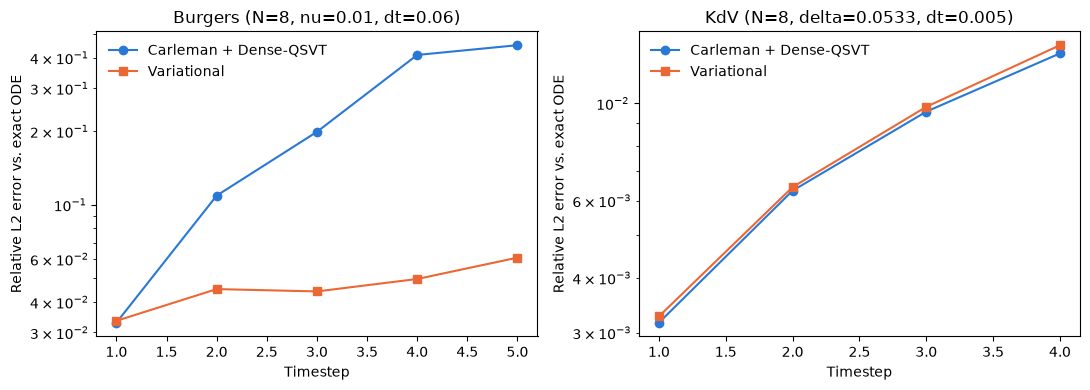

In [6]:
def rel_l2_errors(states, reference):
    return np.array([np.linalg.norm(states[i] - reference[i]) / np.linalg.norm(reference[i])
                      for i in range(1, len(states))])


err_burgers_qsvt = rel_l2_errors(np.array(y_burgers_qsvt), exact_burgers)
err_burgers_var = rel_l2_errors(y_burgers_var, exact_burgers)
err_kdv_qsvt = rel_l2_errors(np.array(y_kdv_qsvt), exact_kdv)
err_kdv_var = rel_l2_errors(y_kdv_var, exact_kdv)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(1, n_steps_burgers + 1), err_burgers_qsvt, "o-", color=DENSE_COLOR, label="Carleman + Dense-QSVT")
axes[0].plot(np.arange(1, n_steps_burgers + 1), err_burgers_var, "s-", color=VARIATIONAL_COLOR, label="Variational")
axes[0].set_yscale("log")
axes[0].set_xlabel("Timestep")
axes[0].set_ylabel("Relative L2 error vs. exact ODE")
axes[0].set_title("Burgers (N=8, nu=0.01, dt=0.06)")
axes[0].legend(frameon=False)

axes[1].plot(np.arange(1, n_steps_kdv + 1), err_kdv_qsvt, "o-", color=DENSE_COLOR, label="Carleman + Dense-QSVT")
axes[1].plot(np.arange(1, n_steps_kdv + 1), err_kdv_var, "s-", color=VARIATIONAL_COLOR, label="Variational")
axes[1].set_yscale("log")
axes[1].set_xlabel("Timestep")
axes[1].set_ylabel("Relative L2 error vs. exact ODE")
axes[1].set_title(f"KdV (N=8, delta={delta}, dt={dt_kdv})")
axes[1].legend(frameon=False)
fig.tight_layout()


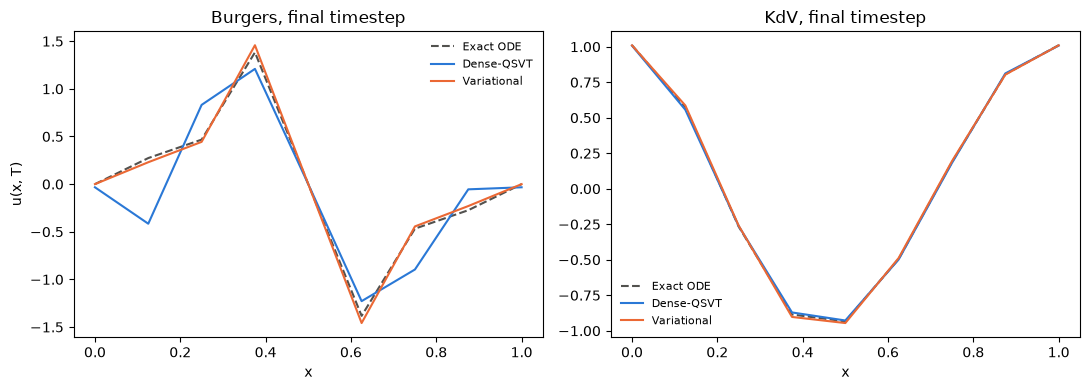

In [7]:
def closed_loop(x, y):
    return np.append(x, x[0] + 1), np.append(y, y[0])


fig, axes = plt.subplots(1, 2, figsize=(11, 4))
xc, exact_b_c = closed_loop(x, exact_burgers[-1])
_, qsvt_b_c = closed_loop(x, np.array(y_burgers_qsvt)[-1])
_, var_b_c = closed_loop(x, y_burgers_var[-1])
axes[0].plot(xc, exact_b_c, "--", color=CLASSICAL_COLOR, label="Exact ODE")
axes[0].plot(xc, qsvt_b_c, "-", color=DENSE_COLOR, label="Dense-QSVT")
axes[0].plot(xc, var_b_c, "-", color=VARIATIONAL_COLOR, label="Variational")
axes[0].set_title("Burgers, final timestep")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x, T)")
axes[0].legend(frameon=False, fontsize=8)

_, exact_k_c = closed_loop(x, exact_kdv[-1])
_, qsvt_k_c = closed_loop(x, np.array(y_kdv_qsvt)[-1])
_, var_k_c = closed_loop(x, y_kdv_var[-1])
axes[1].plot(xc, exact_k_c, "--", color=CLASSICAL_COLOR, label="Exact ODE")
axes[1].plot(xc, qsvt_k_c, "-", color=DENSE_COLOR, label="Dense-QSVT")
axes[1].plot(xc, var_k_c, "-", color=VARIATIONAL_COLOR, label="Variational")
axes[1].set_title("KdV, final timestep")
axes[1].set_xlabel("x")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()


## Resource comparison

Dense-QSVT: one deep circuit (~560 phase-angle layers) per linear solve. Variational: many shallow
circuits (one Hadamard test per cost term, repeated across optimizer iterations). Different shapes,
reported separately. Pauli-LCU numbers below are from the individual pathway notebooks at N=5, not
re-run here (impractical runtime above N~6).


In [8]:
def carleman_matrix(carleman_obj):
    A = carleman_obj.get_I_m_Adt()
    Dim = A.shape[0]
    padded_dim = next_power_of_two(Dim)
    A_padded = np.eye(padded_dim)
    A_padded[:Dim, :Dim] = A
    return A_padded.T, Dim, padded_dim


def dense_qsvt_resources(carleman_obj, label):
    M, Dim, padded_dim = carleman_matrix(carleman_obj)
    n_wires = int(np.ceil(np.log2(M.shape[0]))) + 1
    sigma_min = np.min(np.linalg.svd(M, compute_uv=False))
    layer_stats = res_est.dense_layer_stats(M, n_wires)
    proj_stats = res_est.projector_layer_stats(n_wires, n_ancilla=1)
    total = res_est.extrapolate_total(layer_stats, proj_stats, len(phi_qsvt))
    kappa_eff = layer_stats["norm"] / sigma_min
    print(f"{label}: Dim={Dim} padded={padded_dim} qubits={total['qubits']} "
          f"alpha={layer_stats['norm']:.3f} kappa_eff={kappa_eff:.3f}")
    print(f"  full circuit: gates={total['gate_count']:,} cx={total['two_qubit_gates']:,} depth={total['depth']:,}")
    return total


burgers_qsvt_resources = dense_qsvt_resources(pb_carleman, "Burgers Dense-QSVT (N=8)")
kdv_qsvt_resources = dense_qsvt_resources(kdv_carleman, "KdV Dense-QSVT (N=8)")


Burgers Dense-QSVT (N=8): Dim=72 padded=128 qubits=8 alpha=2.098 kappa_eff=2.341
  full circuit: gates=43,070,392 cx=16,577,145 depth=32,767,463


KdV Dense-QSVT (N=8): Dim=72 padded=128 qubits=8 alpha=1.699 kappa_eff=1.723
  full circuit: gates=43,077,100 cx=16,577,145 depth=32,774,171


In [9]:
def variational_circuit_resources(circuit, label):
    tqc = transpile(circuit, basis_gates=["cx", "u3"], optimization_level=1)
    ops = tqc.count_ops()
    cx = sum(c for g, c in ops.items() if g in ("cx", "cz", "ecr", "swap"))
    print(f"{label}: qubits={tqc.num_qubits} gates={sum(ops.values())} cx={cx} depth={tqc.depth()}")
    return {"qubits": tqc.num_qubits, "gate_count": sum(ops.values()), "two_qubit_gates": cx, "depth": tqc.depth()}


# deepest circuit per cost-function evaluation: the nonlinear-term (convection) circuit,
# 3n+1 qubits, shared by both PDEs since "-u*u_x" is identical
theta_dummy_old = np.random.default_rng(0).normal(size=nparams)
theta_dummy_new = np.random.default_rng(1).normal(size=nparams)
anc, Ra, Rb, chk = 0, list(range(1, 1 + n)), list(range(1 + n, 1 + 2 * n)), list(range(1 + 2 * n, 1 + 3 * n))
qc_nonlinear = QuantumCircuit(1 + 3 * n)
qc_nonlinear.h(anc)
prep = ansatz(n, theta_dummy_old).to_gate().control(1)
qc_nonlinear.append(prep, [anc] + Ra)
qc_nonlinear.append(prep, [anc] + Rb)
qc_nonlinear.append(shift_power(n, 1, True).to_gate().control(1), [anc] + Rb)
for j in range(n):
    qc_nonlinear.cx(Ra[j], chk[j]); qc_nonlinear.cx(Rb[j], chk[j]); qc_nonlinear.cx(Ra[j], Rb[j])
qc_nonlinear.append(ansatz(n, theta_dummy_new).inverse().to_gate().control(1), [anc] + Ra)
qc_nonlinear.h(anc)

variational_nonlinear_resources = variational_circuit_resources(qc_nonlinear, "Variational nonlinear-term circuit (per evaluation)")

qc_linear = QuantumCircuit(n + 1)
qc_linear.h(0)
qc_linear.append(ansatz(n, theta_dummy_old).to_gate().control(1), range(n + 1))
qc_linear.append(shift_power(n, 1, True).to_gate().control(1), range(n + 1))
qc_linear.append(ansatz(n, theta_dummy_new).inverse().to_gate().control(1), range(n + 1))
qc_linear.h(0)
variational_linear_resources = variational_circuit_resources(qc_linear, "Variational linear-term circuit (per evaluation)")


Variational nonlinear-term circuit (per evaluation): qubits=10 gates=478 cx=218 depth=370
Variational linear-term circuit (per evaluation): qubits=4 gates=361 cx=161 depth=286


In [10]:
print("Pauli-LCU (from the individual pathway notebooks, N=5, NOT the same N as above):")
print(f"{'':14s}{'qubits':>8s}{'alpha':>10s}{'kappa_eff':>11s}{'gates':>16s}{'cx':>14s}{'depth':>14s}")
print(f"{'Burgers LCU':14s}{14:>8d}{4.053:>10.3f}{4.65:>11.2f}{1283229363:>16,d}{600388684:>14,d}{948235555:>14,d}")
print(f"{'KdV LCU':14s}{15:>8d}{9.859:>10.3f}{11.76:>11.2f}{2689711074:>16,d}{1260998234:>14,d}{2016039795:>14,d}")


Pauli-LCU (from the individual pathway notebooks, N=5, NOT the same N as above):
                qubits     alpha  kappa_eff           gates            cx         depth
Burgers LCU         14     4.053       4.65   1,283,229,363   600,388,684   948,235,555
KdV LCU             15     9.859      11.76   2,689,711,074 1,260,998,234 2,016,039,795


## Summary

Same N/dt/IC/nu-delta, both methods reproduce the same physics (plots above) at very different
resource cost. Carleman's extra error at Burgers' dt=0.06 (implicit Euler + Carleman truncation
vs. variational's pure explicit Euler) is real, not a bug -- KdV's smaller dt=0.005 shows both
methods agreeing closely instead. Pauli-LCU's cost genuinely doesn't scale to N=8; reported
separately rather than forced into this comparison.
